### Smart Beverage Router
- Using LangGraph to Decide between Coffee or Tea based on User Preferences

In [8]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Literal

#### State: 
  - The state is a simple dictionary that holds all the information as the agent moves through the graph.

In [4]:
"""
In normal dictionary we can have any key and value, but in TypedDict we can specify the type of keys and values.
state["topic"] = "AI"
state["tpoic] = "langgraph"
"""
class SimpleState(TypedDict):
    "Holds the information for the graph"
    topic : str

####  Nodes:
 -  Nodes are the placeholder functions. Their job is simply to read the state, perform an action and return the updated state

In [5]:
def gather_info(state:SimpleState):
    """Node1: Gather initial information"""
    print("---Node 1: GATHER INFORMATION---")
    topic = state["topic"]
    return {"topic": f"Gathered information about {topic}"}


def make_coffee(state:SimpleState):
    """Node2: Make coffee"""
    print("---Node 2: MAKE COFFEE---")
    topic = state["topic"]
    return {"topic": f"{topic}. Result: Coffee is brewed"}


def make_tea(state:SimpleState):
    """Node3: Make tea"""
    print("---Node 3: MAKE TEA---")
    topic = state["topic"]
    return {"topic": f"{topic}. Result: Tea is brewed"}


#### Conditional Edge (The Router)
- The router determines the path based on the initial input (topic)

In [7]:
def decide_beverage(state:SimpleState) -> Literal["make_coffee", "make_tea"]:
    """
    The conditional Edge function: Decides the next node based on the state.
    It must return the name of the NEXT node
    """
    topic = state["topic"]
    print("---DECIDE BEVERAGE---")
    
    # if the user's initial input contains "morning" or "strong", go for coffee, otherwise go for tea
    if "morning" in topic.lower() or "strong" in topic.lower():
        print("-> Decision: Needs COFFEE")
        return "make_coffee"
    else:
        print("-> Decision: Needs TEA")
        return "make_tea"

### Graph Construction and Flow:
- Flow: START -> gather_info -> decide_beverage -> (make_coffee OR make_tea) -> END

In [9]:
# Initializing the graph
builder = StateGraph(SimpleState)

# Adding Nodes
builder.add_node("gather_info", gather_info)
builder.add_node("make_coffee", make_coffee)
builder.add_node("make_tea", make_tea)


# Adding Edges
# Always go from START to gather_info first
builder.add_edge(START, "gather_info")

# From gather_info , use conditional router 'decide_beverage'
builder.add_conditional_edges("gather_info", 
                              decide_beverage,
                              # Map the router function's string output to the actual nodes
                              # Here key=What router returns, value = what node name is
                              # Always give key and value same to avoid confusion
                              {"make_coffee": "make_coffee", "make_tea": "make_tea"}
                              )

# Both make_coffee and make_tea lead to END
builder.add_edge("make_coffee", END)
builder.add_edge("make_tea", END)

# compile the graph
app = builder.compile()

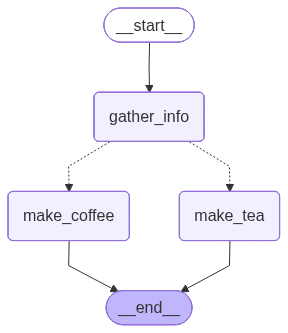

In [12]:
app

### Running the example 


In [13]:
# Example A : Go to Coffee Node
print(" Example A: Asking for a strong morning beverage")
input_a = {"topic": "I want a strong morning beverage"}
result_a = app.invoke(input_a)
print(f"Final State Result A: {result_a}")

 Example A: Asking for a strong morning beverage
---Node 1: GATHER INFORMATION---
---DECIDE BEVERAGE---
-> Decision: Needs COFFEE
---Node 2: MAKE COFFEE---
Final State Result A: {'topic': 'Gathered information about I want a strong morning beverage. Result: Coffee is brewed'}


In [14]:
# Example B : Go to Tea Node
print(" Example B: Asking for a simple afternoon beverage")
input_b = {"topic": "Just a light drink for the afternoon"}
result_b = app.invoke(input_b)
print(f"Final State Result B: {result_b}")

 Example B: Asking for a simple afternoon beverage
---Node 1: GATHER INFORMATION---
---DECIDE BEVERAGE---
-> Decision: Needs TEA
---Node 3: MAKE TEA---
Final State Result B: {'topic': 'Gathered information about Just a light drink for the afternoon. Result: Tea is brewed'}


### Ticket Routing Agent Example

In [15]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Literal

In [16]:
# The central data structure for our ticketing system
class TicketState(TypedDict):
    "Holds the information for the ticketing system"
    # The initial subject/problem description
    subject : str
    # The classification result used for routing
    classification : str
    # the final action taken
    status : str


In [17]:
# Nodes

def classify_ticket(state: TicketState):
    "Node 1: Classifies the incoming ticket by urgency/types"
    print("---Node 1: CLASSIFY TICKET---")
    subject = state["subject"]

    if "billing" in subject.lower() or "login" in subject.lower():
        result = "Billing"
    elif "password" in subject.lower() or "login" in subject.lower():
        result = "Level_1_support"
    else:
        result = "Engineering_Escalation"

    print(f"Ticket classification: {result}")  
    return {"classification": result}      


def handle_level_1(state: TicketState):
    "Node 2: resolve simple L1 issues"
    print("---Node 2: HANDLE LEVEL 1 SUPPORT---")
    return {"status": "Resolved by Level 1 Support"}

def handle_billing(state: TicketState):
    "Node 3: resolve billing issues"
    print("---Node 3: HANDLE BILLING---")
    return {"status": "Resolved by Billing Team"}

def escalate_to_eng(state: TicketState):
    "Node 4: Escalate complex issues to engineering"
    print("---Node 4: ESCALATE TO ENGINEERING---")
    return {"status": "Escalated to Engineering Team"}


In [18]:
# Define the conditional edge
def route_ticket(state: TicketState) -> Literal["handle_level_1", "handle_billing", "escalate_to_eng"]:
    "Conditional Edge: Routes the ticket based on classification"
    classification = state["classification"]
    print("---ROUTE TICKET---")
    
    if classification == "Billing":
        print("-> Routing to BILLING")
        return "handle_billing"
    elif classification == "Level_1_support":
        print("-> Routing to LEVEL 1 SUPPORT")
        return "handle_level_1"
    else:
        print("-> Routing to ENGINEERING ESCALATION")
        return "escalate_to_eng"

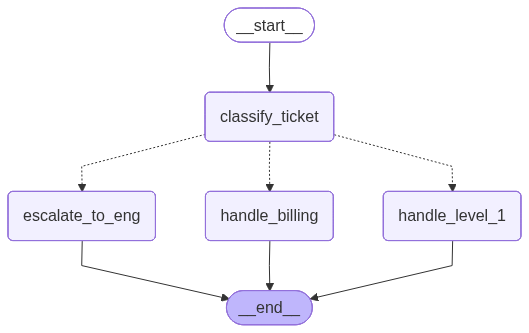

In [19]:
# Graph construction
builder = StateGraph(TicketState)

# Adding Nodes
builder.add_node("classify_ticket", classify_ticket)
builder.add_node("handle_level_1", handle_level_1)
builder.add_node("handle_billing", handle_billing)
builder.add_node("escalate_to_eng", escalate_to_eng)


# Adding Edges
builder.add_edge(START, "classify_ticket")
builder.add_conditional_edges("classify_ticket", 
                              route_ticket,
                              {"handle_level_1": "handle_level_1", 
                               "handle_billing": "handle_billing", 
                               "escalate_to_eng": "escalate_to_eng"}
                              )

builder.add_edge("handle_level_1", END)
builder.add_edge("handle_billing", END)
builder.add_edge("escalate_to_eng", END)
app = builder.compile()

app

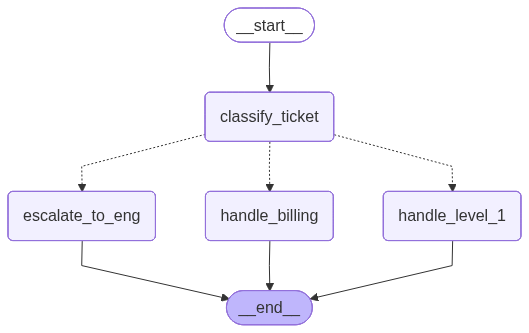

In [24]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

### Run the examples


- Scenario A: Simple Login Issue

In [22]:
print("Scenario A: Simple L1 Support Issue")
input_a = {"subject": "I can't log into my account, I need a password reset"}
result_a = app.invoke(input_a)
print(f"Result for Scenario A: {result_a}")

Scenario A: Simple L1 Support Issue
---Node 1: CLASSIFY TICKET---
Ticket classification: Level_1_support
---ROUTE TICKET---
-> Routing to LEVEL 1 SUPPORT
---Node 2: HANDLE LEVEL 1 SUPPORT---
Result for Scenario A: {'subject': "I can't log into my account, I need a password reset", 'classification': 'Level_1_support', 'status': 'Resolved by Level 1 Support'}


- Scenario B: Engineering Escalation

In [23]:
print("Scenario B: Complex Engineering Issue")
input_b = {"subject": "The system crashes when I try to upload a large file"}
result_b = app.invoke(input_b)
print(f"Result for Scenario B: {result_b}")

Scenario B: Complex Engineering Issue
---Node 1: CLASSIFY TICKET---
Ticket classification: Engineering_Escalation
---ROUTE TICKET---
-> Routing to ENGINEERING ESCALATION
---Node 4: ESCALATE TO ENGINEERING---
Result for Scenario B: {'subject': 'The system crashes when I try to upload a large file', 'classification': 'Engineering_Escalation', 'status': 'Escalated to Engineering Team'}
